# Word Embeddings for Document Classification : Practice & Experiments
**Authored by Alexandre Mathias DONNAT, Sr - Télécom Paris**

This notebook explores and compares multiple text representation techniques(ranging from sparse bag-of-words models to dense topic-based and prediction-based embeddings)by evaluating their effectiveness on a multi-class text classification task.

## Objectives:

Explore the various way to represent textual data by applying them to a relatively small classification dataset - **20NewsGroup** - try to  look at how they perform on the classification task. 
1. Pre-process the data: clean it, obtain an appropriate vocabulary.
2. Obtain representations: any that will allow us to obtain a vector representation of each document is appropriate.
    - Dense document representations: via **Topic Modeling: LSA, LDA**
        - Obtain them from symbolic document representations: **BoW, TF-IDF**
    - Dense word representations: **SVD-reduced PPMI, Word2vec, GloVe** 
3. Perform classification: we can make things simple and only use a **logistic regression**
    - We will compare symbolic document representations with an *aggregate* of the various dense words representations we used.
        - For these, we will need to implement a **function aggregating word representations into document representations**
    - Compare results, looking at raw performance metrics and confusion matrices. We'll give our analysis of the advantage and disadvantage of each method. 

## Necessary dependancies

We will need the following packages:
- The Machine Learning API Scikit-learn : http://scikit-learn.org/stable/install.html
- The Natural Language Toolkit : http://www.nltk.org/install.html
- Gensim: https://radimrehurek.com/gensim/

These are available with Anaconda: https://anaconda.org/anaconda/nltk and https://anaconda.org/anaconda/scikit-learn

In [6]:
import os.path as op
import re 
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

## Loading data

We retrieve the textual data in the variable *texts*.

The labels are retrieved in the variable $y$ - it contains *len(texts)* of them: $0$ indicates that the corresponding review is negative while $1$ indicates that it is positive.

In [7]:
from sklearn.datasets import fetch_20newsgroups

In [8]:
ng_train = fetch_20newsgroups(subset='train',
                              remove=('headers', 'footers', 'quotes')
                              )

In [9]:
pprint(dir(ng_train))

['DESCR', 'data', 'filenames', 'target', 'target_names']


In [10]:
pprint(ng_train.target_names)

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']


Example of one document:

In [11]:
pprint(ng_train.data[0])
print("Target: ", ng_train.target_names[ng_train.target[0]])

('I was wondering if anyone out there could enlighten me on this car I saw\n'
 'the other day. It was a 2-door sports car, looked to be from the late 60s/\n'
 'early 70s. It was called a Bricklin. The doors were really small. In '
 'addition,\n'
 'the front bumper was separate from the rest of the body. This is \n'
 'all I know. If anyone can tellme a model name, engine specs, years\n'
 'of production, where this car is made, history, or whatever info you\n'
 'have on this funky looking car, please e-mail.')
Target:  rec.autos


## 1 - Document Preprocessing

We should use a pre-processing function we can apply to the raw text before any other processing (*i.e*, tokenization and obtaining representations). Some pre-processing can also be tied with the tokenization (*i.e*, removing stop words).

In [12]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
import unidecode
import string

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alexa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
def clean_text(text: str,
               rm_numbers=True,
               rm_punct=True,
               rm_stop_words=True,
               rm_short_words=True):
    # make lowercase
    text = text.lower()

    # remove punctuation
    if rm_punct:
        text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))

    # remove numbers
    if rm_numbers:
        text = re.sub(r'\d+', '', text)

    # remove whitespaces
    text = text.strip()

    # remove stopwords
    if rm_stop_words:
        stop_words = set(stopwords.words('english'))
        word_tokens = word_tokenize(text)
        text_list = [w for w in word_tokens if not w in stop_words]
        text = ' '.join(text_list)

    # remove short words
    if rm_short_words:
        text_list = [w for w in text.split() if len(w) >= 3]
        text = ' '.join(text_list)

    return text

In [15]:
pprint(clean_text(ng_train.data[0]))

('wondering anyone could enlighten car saw day door sports car looked late '
 'early called bricklin doors really small addition front bumper separate rest '
 'body know anyone tellme model name engine specs years production car made '
 'history whatever info funky looking car please mail')


The dataset contains 20 classes. However, **some of them are pretty close together. We aggregate them into 6 semantically coherent classes** which should not be easier to distinguish:

In [16]:
def aggregate_labels(label):
    # comp
    if label in [1,2,3,4,5]:
        new_label = 0
    # rec
    if label in [7,8,9,10]:
        new_label = 1
    # sci
    if label in [11,12,13,14]:
        new_label = 2
    # misc 
    if label in [6]:
        new_label = 3
    # pol
    if label in [16,17,18]:
        new_label = 4
    # rel
    if label in [0,15,19]:
        new_label = 5
    return new_label

We check that **we don't have any empty document**:

In [17]:
ng_train_text = [clean_text(ng_train.data[i]) for i in range(len(ng_train.data)) if len(clean_text(ng_train.data[i])) > 0]
ng_train_labels = [aggregate_labels(ng_train.target[i]) for i in range(len(ng_train.data)) if len(clean_text(ng_train.data[i])) > 0]

In [18]:
ng_test = fetch_20newsgroups(subset='test',
                             remove=('headers', 'footers', 'quotes')
                            )

ng_test_text = [clean_text(ng_test.data[i]) for i in range(len(ng_test.data)) if len(clean_text(ng_test.data[i])) > 0]
ng_test_labels = [aggregate_labels(ng_test.target[i]) for i in range(len(ng_test.data)) if len(clean_text(ng_test.data[i])) > 0]

We could use the tokenizer form ```sklearn```'s class ```CountVectorizer``` and let it create a vocabulary. But, for later methods (Word2vec, Glove) that could be too many words. We will hence create a vocabulary function now, and we will use the same for the remaining of the lab:

In [19]:
def vocabulary(corpus, voc_threshold=0):
    """    
    Function using word counts to build a vocabulary - can be improved with a second parameter for 
    setting a frequency threshold
    Params:
        corpus (list of list of strings): corpus of sentences
        voc_threshold (int): maximum size of the vocabulary (0 means no limit !)
    Returns:
        vocabulary (dictionary): keys: list of distinct words across the corpus
                                 values: indexes corresponding to each word sorted by frequency        
    """  
    word_counts = {}
    for sent in corpus:
        for word in word_tokenize(sent):
            if (word not in word_counts):
                word_counts[word] = 0
            word_counts[word] += 1           
    words = sorted(word_counts.keys(), key=word_counts.get, reverse=True)
    if voc_threshold > 0:
        words = words[:voc_threshold] + ['unk']   
    vocabulary = {words[i] : i for i in range(len(words))}
    return vocabulary, {word: word_counts.get(word, 0) for word in vocabulary}

Let's take a look at the distribution of word frequencies:

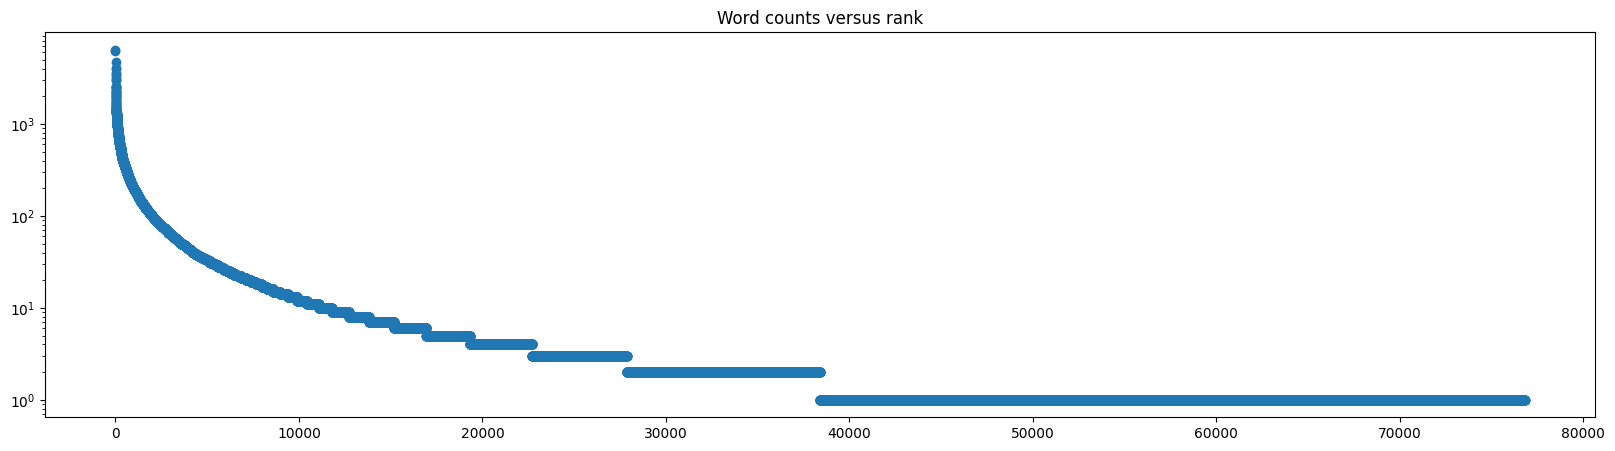

Vocabulary size: 76801
Part of the corpus by taking the "x" most frequent words:
5000 : 0.76
10000 : 0.86
15000 : 0.90
20000 : 0.92
25000 : 0.94
30000 : 0.95
35000 : 0.96
40000 : 0.97
45000 : 0.97
50000 : 0.98
55000 : 0.98
60000 : 0.98
65000 : 0.99
70000 : 0.99
75000 : 1.00


In [20]:
vocab, word_counts = vocabulary(ng_train_text)
rank_counts = {w:[vocab[w], word_counts[w]] for w in vocab}
rank_counts_array = np.array(list(rank_counts.values()))

plt.figure(figsize=(20,5))
plt.title('Word counts versus rank')
plt.scatter(rank_counts_array[:,0], rank_counts_array[:,1])
plt.yscale('log')
plt.show()

print('Vocabulary size: %i' % len(vocab))
print('Part of the corpus by taking the "x" most frequent words:')
for i in range(5000, len(vocab), 5000):
    print('%i : %.2f' % (i, np.sum(rank_counts_array[:i, 1]) / np.sum(rank_counts_array[:,1]) ))

In [21]:
vocab, word_counts = vocabulary(ng_train_text, 5000)

## 2 - Symbolic text representations

We can use the ```CountVectorizer``` class from scikit-learn to obtain the first set of representations:
- Use the appropriate argument to get our own vocabulary
- Fit the vectorizer on our training data, transform our test data
- Create a ```LogisticRegression``` model and train it with these representations. Display the confusion matrix using functions from ```sklearn.metrics``` 

Then, re-execute the same pipeline with the ```TfidfVectorizer```.

<div class='alert alert-block alert-info'>
            Code:</div>

In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

BoW accuracy: 0.7666803671735855
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1909
           1       0.78      0.85      0.81      1524
           2       0.70      0.69      0.70      1520
           3       0.78      0.68      0.73       382
           4       0.75      0.67      0.71      1025
           5       0.75      0.75      0.75       939

    accuracy                           0.77      7299
   macro avg       0.76      0.75      0.75      7299
weighted avg       0.77      0.77      0.77      7299



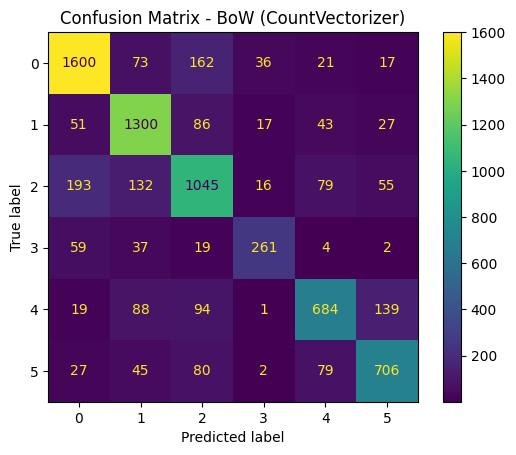

In [23]:
vectorizer_bow = CountVectorizer(vocabulary=vocab)  

X_train_bow = vectorizer_bow.fit_transform(ng_train_text) 
X_test_bow  = vectorizer_bow.transform(ng_test_text)

clf_bow = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    multi_class="auto"
)
clf_bow.fit(X_train_bow, ng_train_labels)

y_pred_bow = clf_bow.predict(X_test_bow)

print("BoW accuracy:", accuracy_score(ng_test_labels, y_pred_bow))
print(classification_report(ng_test_labels, y_pred_bow))

cm_bow = confusion_matrix(ng_test_labels, y_pred_bow)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bow)
disp.plot(values_format="d")
plt.title("Confusion Matrix - BoW (CountVectorizer)")
plt.show()

TF-IDF accuracy: 0.801068639539663
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1909
           1       0.81      0.87      0.84      1524
           2       0.74      0.74      0.74      1520
           3       0.89      0.59      0.71       382
           4       0.80      0.73      0.76      1025
           5       0.81      0.75      0.78       939

    accuracy                           0.80      7299
   macro avg       0.81      0.76      0.78      7299
weighted avg       0.80      0.80      0.80      7299



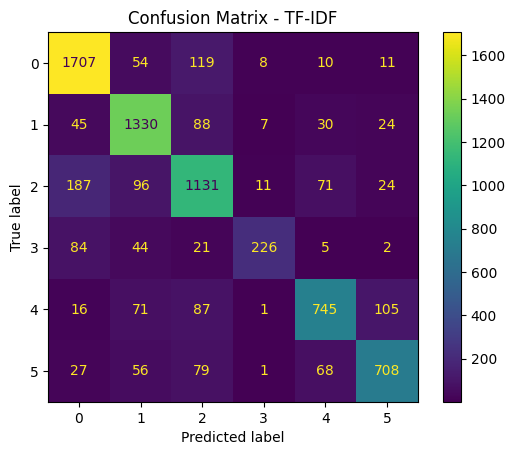

In [24]:
vectorizer_tfidf = TfidfVectorizer(vocabulary=vocab)

X_train_tfidf = vectorizer_tfidf.fit_transform(ng_train_text)
X_test_tfidf  = vectorizer_tfidf.transform(ng_test_text)

clf_tfidf = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    multi_class="auto"
)
clf_tfidf.fit(X_train_tfidf, ng_train_labels)

y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

print("TF-IDF accuracy:", accuracy_score(ng_test_labels, y_pred_tfidf))
print(classification_report(ng_test_labels, y_pred_tfidf))

cm_tfidf = confusion_matrix(ng_test_labels, y_pred_tfidf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf)
disp.plot(values_format="d")
plt.title("Confusion Matrix - TF-IDF")
plt.show()

Both symbolic approaches achieve strong baselines on the 6-class classification task.  
TF-IDF slightly outperforms raw Bag-of-Words (≈ 80 % vs 77 % accuracy), which suggests that down-weighting very frequent terms and emphasizing more discriminative words improves class separation.  
The confusion matrices show that most errors occur between semantically close classes, indicating that the remaining ambiguity is mainly semantic rather than lexical.

## 3 - Dense Representations from Topic Modeling

Now, the goal is to re-use the bag-of-words representations we obtained earlier - but reduce their dimension through a **topic model**. Note that this allows to obtain reduced **document representations**, which we can again use directly to perform classification.
- Do this with two models: ```TruncatedSVD``` and ```LatentDirichletAllocation```
- Pick $300$ as the dimensionality of the latent representation (*i.e*, the number of topics)

<div class='alert alert-block alert-info'>
            Code:</div>

LSA (TruncatedSVD) accuracy: 0.7833949856144677
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      1909
           1       0.78      0.87      0.82      1524
           2       0.72      0.73      0.72      1520
           3       0.89      0.55      0.68       382
           4       0.79      0.71      0.75      1025
           5       0.81      0.72      0.76       939

    accuracy                           0.78      7299
   macro avg       0.80      0.74      0.76      7299
weighted avg       0.79      0.78      0.78      7299



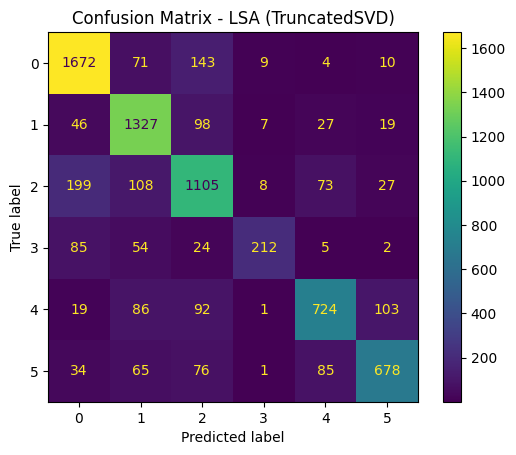

In [ ]:
from sklearn.decomposition import TruncatedSVD

# TF-IDF representations already built previously
svd = TruncatedSVD(n_components=300, random_state=0)

X_train_lsa = svd.fit_transform(X_train_tfidf)
X_test_lsa  = svd.transform(X_test_tfidf)

clf_lsa = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    multi_class="auto"
)
clf_lsa.fit(X_train_lsa, ng_train_labels)

y_pred_lsa = clf_lsa.predict(X_test_lsa)

print("LSA (TruncatedSVD) accuracy:", accuracy_score(ng_test_labels, y_pred_lsa))
print(classification_report(ng_test_labels, y_pred_lsa))

cm_lsa = confusion_matrix(ng_test_labels, y_pred_lsa)
ConfusionMatrixDisplay(cm_lsa).plot(values_format="d")
plt.title("Confusion Matrix - LSA (TruncatedSVD)")
plt.show()

LDA accuracy: 0.7333881353610083
              precision    recall  f1-score   support

           0       0.75      0.86      0.80      1909
           1       0.76      0.79      0.78      1524
           2       0.64      0.65      0.64      1520
           3       0.81      0.48      0.60       382
           4       0.73      0.69      0.71      1025
           5       0.79      0.68      0.73       939

    accuracy                           0.73      7299
   macro avg       0.75      0.69      0.71      7299
weighted avg       0.74      0.73      0.73      7299



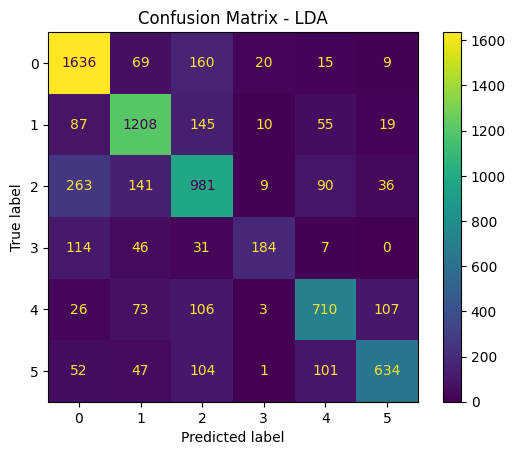

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# X_train_bow, X_test_bow from Part 2
lda = LatentDirichletAllocation(
    n_components=300,
    max_iter=10,
    learning_method="batch",
    random_state=0
)

X_train_lda = lda.fit_transform(X_train_bow)
X_test_lda  = lda.transform(X_test_bow)

clf_lda = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    multi_class="auto"
)
clf_lda.fit(X_train_lda, ng_train_labels)

y_pred_lda = clf_lda.predict(X_test_lda)

print("LDA accuracy:", accuracy_score(ng_test_labels, y_pred_lda))
print(classification_report(ng_test_labels, y_pred_lda))

cm_lda = confusion_matrix(ng_test_labels, y_pred_lda)
ConfusionMatrixDisplay(cm_lda).plot(values_format="d")
plt.title("Confusion Matrix - LDA")
plt.show()

In [27]:
results = {
    "BoW": accuracy_score(ng_test_labels, y_pred_bow),
    "TF-IDF": accuracy_score(ng_test_labels, y_pred_tfidf),
    "LSA (SVD)": accuracy_score(ng_test_labels, y_pred_lsa),
    "LDA": accuracy_score(ng_test_labels, y_pred_lda),
}

pprint(results)

{'BoW': 0.7666803671735855,
 'LDA': 0.7333881353610083,
 'LSA (SVD)': 0.7833949856144677,
 'TF-IDF': 0.801068639539663}


Dense document representations obtained via topic modeling lead to mixed results.  
LSA (TruncatedSVD) slightly improves over raw Bag-of-Words but remains below TF-IDF, suggesting that linear dimensionality reduction preserves part of the discriminative structure while losing some fine-grained lexical information.  
LDA performs worse overall, indicating that probabilistic topic mixtures, while interpretable, are less suited for supervised classification when semantic classes overlap.

<div class='alert alert-block alert-warning'>
            Question:</div>
            
We picked $300$ as number of topics. What would be the procedure to follow if we wanted to choose this hyperparameter through the data ? 

To select the number of topics in a data-driven way, the dataset should be split into training and validation sets.  
For a range of candidate values (e.g. 50, 100, 200, 300, 500 topics), the topic model is fitted on the training data, document representations are computed, and a downstream classifier is trained and evaluated on the validation set.  
The optimal number of topics is then chosen by maximizing a validation criterion such as classification accuracy or macro F1-score, possibly complemented by stability or interpretability considerations.

## 4 - Dense Count-based Representations

The following function allows to obtain very large-dimensional vectors for **words**. We will now follow a different procedure:
- Use ```TruncatedSVD```to obtain **word embeddings** of dimension $300$ from the output of the ```co_occurence_matrix```function, to which we can apply any intermediate transformation we see fit. 
- Complete the following ```sentence_representations``` matrix, which will allow we to obtain **document representations** from **word embeddings**. 
- Put the pipeline together and obtain document representations for both training and testing data, using word embeddings we got from the *training data co-occurence matrix*.
- Apply the same classification model as before, and display the results.
<div class='alert alert-block alert-info'>
            Code:</div>

In [ ]:
def co_occurence_matrix(corpus, vocabulary, window=0, distance_weighting=False):
    """
    Params:
        corpus (list of strings OR list of list of strings): corpus of sentences
        vocabulary (dictionary): words to use in the matrix (word -> index)
        window (int): size of the context window; when 0, the context is the whole sentence
        distance_weighting (bool): indicates if we use a weight depending on the distance between words for co-oc counts
    Returns:
        matrix (array of size (len(vocabulary), len(vocabulary))): the co-oc matrix    
    """ 
    l = len(vocabulary)
    M = np.zeros((l, l), dtype=float)

    for sent in corpus:
        # Get the sentence tokens
        if isinstance(sent, str):
            sent_tok = sent.split()
        else:
            sent_tok = sent  

        # Obtain the indexes of the words in the sentence from the vocabulary 
        sent_idx = [vocabulary[w] for w in sent_tok if w in vocabulary]

        # Avoid one-word sentences - can create issues in normalization:
        if len(sent_idx) == 1:
            sent_idx.append(len(vocabulary) - 1)

        # Go through the indexes and add 1 / dist(i,j) to M[i,j] if words appear in the same window
        for i, idx in enumerate(sent_idx):

            # If we consider a limited context:
            if window > 0:
                # indexes on the left within the window
                l_ctx_idx = sent_idx[max(0, i - window): i]
            # If the context is the entire document:
            else:
                l_ctx_idx = sent_idx[:i]

            # Update M for each left-context word
            for j, ctx_idx in enumerate(l_ctx_idx):
                if distance_weighting:
                    weight = 1.0 / (len(l_ctx_idx) - j)
                else:
                    weight = 1.0

                M[idx, ctx_idx] += weight
                M[ctx_idx, idx] += weight

    return M

<div class='alert alert-block alert-info'>
            Code:</div>

In [ ]:
def sentence_representations(texts, vocabulary, embeddings, np_func=np.mean):
    """
    Represent the sentences as a combination of the vector of its words.
    Parameters
    ----------
    texts : a list of sentences (strings)
    vocabulary : dict (word -> index)
    embeddings : matrix (|V|, d)
    np_func : function (default: np.mean)
        A numpy matrix operation that can be applied columnwise,
        like `np.mean`, `np.sum`, or `np.prod`.
    Returns
    -------
    np.array, dimension `(len(texts), embeddings.shape[1])`
    """
    representations = []
    d = embeddings.shape[1]
    unk_idx = vocabulary.get("unk", None)

    for sent in texts:
        tokens = sent.split() if isinstance(sent, str) else sent
        idxs = [vocabulary[w] for w in tokens if w in vocabulary]

        # handle empty sentence after filtering
        if len(idxs) == 0:
            if unk_idx is not None:
                idxs = [unk_idx]
            else:
                representations.append(np.zeros(d))
                continue

        vecs = embeddings[idxs]               
        sent_vec = np_func(vecs, axis=0)        
        representations.append(sent_vec)

    return np.vstack(representations)

<div class='alert alert-block alert-info'>
            Code:</div>

Dense count-based (PPMI + SVD) accuracy: 0.7787368132620907
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1909
           1       0.83      0.82      0.83      1524
           2       0.73      0.72      0.73      1520
           3       0.71      0.68      0.69       382
           4       0.74      0.71      0.73      1025
           5       0.73      0.76      0.74       939

    accuracy                           0.78      7299
   macro avg       0.76      0.76      0.76      7299
weighted avg       0.78      0.78      0.78      7299



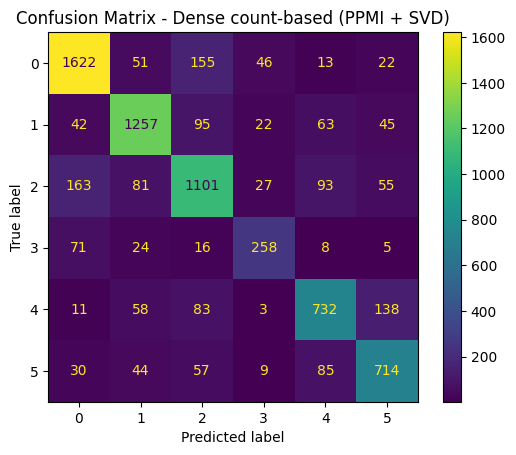

In [ ]:
from sklearn.decomposition import TruncatedSVD

M_train = co_occurence_matrix(
    ng_train_text,
    vocab,
    window=5,                
    distance_weighting=True   
)

eps = 1e-12
M = M_train + eps
total = M.sum()

Pij = M / total
Pi = Pij.sum(axis=1, keepdims=True)
Pj = Pij.sum(axis=0, keepdims=True)

PMI = np.log(Pij / (Pi @ Pj))
PPMI = np.maximum(PMI, 0.0)

svd_words = TruncatedSVD(n_components=300, random_state=0)
word_embeddings = svd_words.fit_transform(PPMI)   

X_train_dense = sentence_representations(ng_train_text, vocab, word_embeddings, np_func=np.mean)
X_test_dense  = sentence_representations(ng_test_text,  vocab, word_embeddings, np_func=np.mean)

clf_dense = LogisticRegression(max_iter=2000, solver="lbfgs", multi_class="auto")
clf_dense.fit(X_train_dense, ng_train_labels)

y_pred_dense = clf_dense.predict(X_test_dense)

print("Dense count-based (PPMI + SVD) accuracy:", accuracy_score(ng_test_labels, y_pred_dense))
print(classification_report(ng_test_labels, y_pred_dense))

cm_dense = confusion_matrix(ng_test_labels, y_pred_dense)
ConfusionMatrixDisplay(cm_dense).plot(values_format="d")
plt.title("Confusion Matrix - Dense count-based (PPMI + SVD)")
plt.show()

Dense word embeddings obtained from a co-occurrence matrix and reduced via SVD yield competitive results, with performance comparable to LSA and slightly below TF-IDF.  
This suggests that aggregating word-level semantic information captures meaningful structure, but that simple averaging of embeddings may lose discriminative signals present in sparse, high-dimensional representations.  
The confusion matrix again highlights errors between semantically close classes, indicating that limitations are mainly due to representation expressiveness rather than classifier capacity.

## 5 - Dense Prediction-based Representations

We will now use two types of word embeddings: 
1. From ```Word2Vec```: which we will train ourselves
2. From ```GloVe```: which we will import like in the demo

We will use the ```gensim``` library for its implementation of word2vec in python. Since we want to keep the same vocabulary as before: we'll first create the class, then get the vocabulary we generated above. 

In [34]:
from gensim.models import Word2Vec
import gensim.downloader as api

In [35]:
model = Word2Vec(vector_size=300,
                 window=5,
                 null_word=len(word_counts))
model.build_vocab_from_freq(word_counts)

<div class='alert alert-block alert-info'>
            Code:</div>

In [36]:
# The model is to be trained with a list of tokenized sentences, containing the full training dataset.
preprocessed_corpus = [sent.split() for sent in ng_train_text]

In [37]:
model.train(preprocessed_corpus, total_examples=len(ng_train_text), epochs=30, report_delay=1)

(24580561, 32824500)

Then, we can re-use the ```sentence_representations```function like before to obtain document representations, and apply classification. 
<div class='alert alert-block alert-info'>
            Code:</div>

Word2Vec accuracy: 0.7699684888340869
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1909
           1       0.82      0.82      0.82      1524
           2       0.70      0.72      0.71      1520
           3       0.73      0.64      0.68       382
           4       0.73      0.70      0.72      1025
           5       0.72      0.77      0.74       939

    accuracy                           0.77      7299
   macro avg       0.76      0.75      0.75      7299
weighted avg       0.77      0.77      0.77      7299



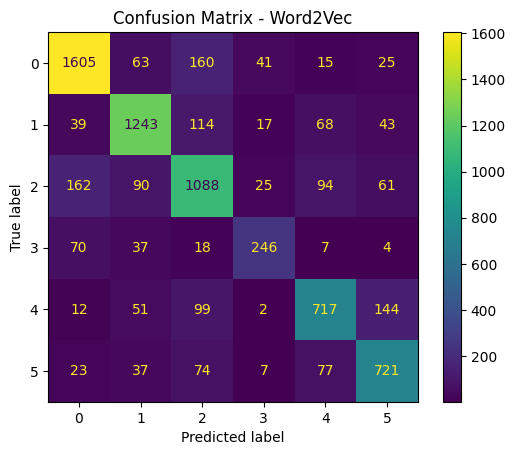

In [38]:
# Obtain word embeddings matrix aligned with our vocabulary
word2vec_embeddings = np.zeros((len(vocab), model.vector_size))

for word, idx in vocab.items():
    if word in model.wv:
        word2vec_embeddings[idx] = model.wv[word]

# Document representations
X_train_w2v = sentence_representations(
    ng_train_text, vocab, word2vec_embeddings, np_func=np.mean
)
X_test_w2v = sentence_representations(
    ng_test_text, vocab, word2vec_embeddings, np_func=np.mean
)

# Classification
clf_w2v = LogisticRegression(max_iter=2000, solver="lbfgs", multi_class="auto")
clf_w2v.fit(X_train_w2v, ng_train_labels)

y_pred_w2v = clf_w2v.predict(X_test_w2v)

print("Word2Vec accuracy:", accuracy_score(ng_test_labels, y_pred_w2v))
print(classification_report(ng_test_labels, y_pred_w2v))

cm_w2v = confusion_matrix(ng_test_labels, y_pred_w2v)
ConfusionMatrixDisplay(cm_w2v).plot(values_format="d")
plt.title("Confusion Matrix - Word2Vec")
plt.show()

Obtain the GloVe representations corresponding to the vocabulary and use them the same way !
<div class='alert alert-block alert-info'>
            Code:</div>

In [39]:
def get_glove_voc_and_embeddings(glove_model):
    voc = {word : index for word, index in enumerate(glove_model.index_to_key)}
    voc['UNK'] = len(voc)
    embeddings = glove_model.vectors
    return voc, embeddings

In [40]:
def get_glove_adapted_embeddings(glove_model, input_voc):
    keys = {i: glove_model.key_to_index.get(w, None) for w, i in input_voc.items()}
    index_dict = {i: key for i, key in keys.items() if key is not None}
    embeddings = np.zeros((len(input_voc),glove_model.vectors.shape[1]))
    for i, ind in index_dict.items():
        embeddings[i] = glove_model.vectors[ind]
    return embeddings

In [41]:
loaded_glove_model = api.load("glove-wiki-gigaword-300")
loaded_glove_embeddings = loaded_glove_model.vectors
loaded_glove_voc, loaded_glove_embeddings = get_glove_voc_and_embeddings(loaded_glove_model)
GloveEmbeddings = get_glove_adapted_embeddings(loaded_glove_model, vocab)

[==================================================] 100.0% 376.1/376.1MB downloaded


GloVe accuracy: 0.7707905192492123
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1909
           1       0.82      0.83      0.83      1524
           2       0.69      0.71      0.70      1520
           3       0.74      0.58      0.65       382
           4       0.74      0.73      0.74      1025
           5       0.76      0.77      0.77       939

    accuracy                           0.77      7299
   macro avg       0.76      0.74      0.75      7299
weighted avg       0.77      0.77      0.77      7299



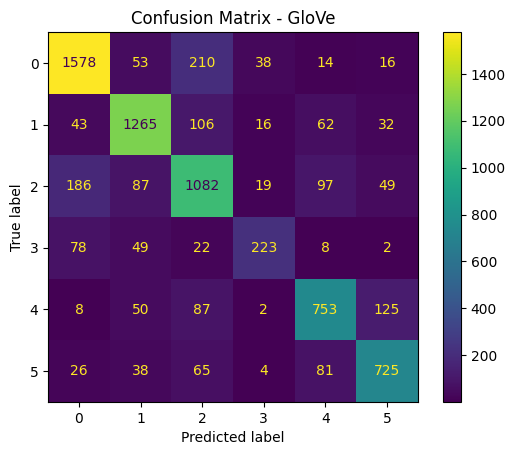

In [42]:
# Document representations with GloVe
X_train_glove = sentence_representations(
    ng_train_text, vocab, GloveEmbeddings, np_func=np.mean
)
X_test_glove = sentence_representations(
    ng_test_text, vocab, GloveEmbeddings, np_func=np.mean
)

# Classification
clf_glove = LogisticRegression(max_iter=2000, solver="lbfgs", multi_class="auto")
clf_glove.fit(X_train_glove, ng_train_labels)

y_pred_glove = clf_glove.predict(X_test_glove)

print("GloVe accuracy:", accuracy_score(ng_test_labels, y_pred_glove))
print(classification_report(ng_test_labels, y_pred_glove))

cm_glove = confusion_matrix(ng_test_labels, y_pred_glove)
ConfusionMatrixDisplay(cm_glove).plot(values_format="d")
plt.title("Confusion Matrix - GloVe")
plt.show()

Prediction-based word embeddings lead to performance comparable to dense count-based representations, but do not outperform TF-IDF on this classification task.  
Word2Vec and GloVe yield very similar results, suggesting that pre-trained semantic information (GloVe) does not provide a strong advantage over embeddings learned directly on the corpus when document representations are obtained via simple averaging.  
The confusion matrices show persistent confusion between semantically close classes, highlighting that limitations mainly arise from the document-level aggregation strategy rather than from the quality of the word embeddings themselves.

<div class='alert alert-block alert-warning'>
            Question:</div>
            
Aggregate all results in a table. Which metric should we look at, and why ? 

| Representation                     | Accuracy |
|-----------------------------------|----------|
| Bag-of-Words (BoW)                | 0.77     |
| TF-IDF                            | 0.80     |
| LSA (TruncatedSVD)                | 0.78     |
| LDA                               | 0.73     |
| Dense count-based (PPMI + SVD)    | 0.78     |
| Word2Vec                          | 0.77     |
| GloVe                             | 0.77     |

In this multi-class classification setting with moderately imbalanced classes, accuracy provides a clear global view of performance but may hide class-specific errors.  
Macro-averaged F1-score is therefore a more informative metric, as it gives equal importance to all classes and highlights difficulties on smaller or harder categories.  
Weighted F1-score can also be considered, but macro F1 is preferable here to assess the robustness of representations across all semantic groups.

<div class='alert alert-block alert-warning'>
            Question:</div>
            
Comment on the results. Is anything noticeable in the confusion matrices ? What do we expect would happen if we used more training data ? or less ? 

Several consistent patterns emerge from the confusion matrices across all representations.  
Most classification errors occur between semantically close classes, indicating that ambiguity is primarily semantic rather than due to insufficient modeling capacity.  
TF-IDF consistently outperforms dense representations, suggesting that sparse lexical features remain highly discriminative for this dataset.

With more training data, prediction-based embeddings (Word2Vec, GloVe) would likely improve, as they benefit from larger corpora to learn richer semantic structures.  
Conversely, with less training data, simpler representations such as TF-IDF would be expected to remain more robust, while dense models would suffer from insufficient signal and higher variance.

<div class='alert alert-block alert-info'>
            Code:</div>
            
Apply the same aggregation function ```sentence_representation``` to **word representations** from the LSA and LDA models. How does it compare to the document representations ? How do we explain these results ?

In [ ]:
# LSA word embeddings
# V^T from SVD corresponds to word components
lsa_word_embeddings = svd.components_.T   # shape: (|V|, 300)

# Aggregate into document representations
X_train_lsa_word = sentence_representations(
    ng_train_text, vocab, lsa_word_embeddings, np_func=np.mean
)
X_test_lsa_word = sentence_representations(
    ng_test_text, vocab, lsa_word_embeddings, np_func=np.mean
)

# Classification
clf_lsa_word = LogisticRegression(max_iter=2000, solver="lbfgs", multi_class="auto")
clf_lsa_word.fit(X_train_lsa_word, ng_train_labels)

y_pred_lsa_word = clf_lsa_word.predict(X_test_lsa_word)

print("LSA word-aggregated accuracy:", accuracy_score(ng_test_labels, y_pred_lsa_word))

LSA word-aggregated accuracy: 0.6174818468283326


In [ ]:
# LDA word embeddings
# topic-word distributions: shape (n_topics, |V|)
lda_word_embeddings = lda.components_.T    # shape: (|V|, 300)

# Aggregate into document representations
X_train_lda_word = sentence_representations(
    ng_train_text, vocab, lda_word_embeddings, np_func=np.mean
)
X_test_lda_word = sentence_representations(
    ng_test_text, vocab, lda_word_embeddings, np_func=np.mean
)

# Classification
clf_lda_word = LogisticRegression(max_iter=2000, solver="lbfgs", multi_class="auto")
clf_lda_word.fit(X_train_lda_word, ng_train_labels)

y_pred_lda_word = clf_lda_word.predict(X_test_lda_word)

print("LDA word-aggregated accuracy:", accuracy_score(ng_test_labels, y_pred_lda_word))

LDA word-aggregated accuracy: 0.7388683381285107


Applying the sentence aggregation function to word representations derived from LSA and LDA leads to significantly worse performance compared to their native document-level representations, especially in the case of LSA.  
This confirms that LSA and LDA are not designed to produce meaningful word embeddings: their latent components capture global document–topic or topic–word structures rather than local semantic information at the word level.

The sharp drop observed for LSA when aggregating word components highlights that its dimensions encode directions of maximal variance in the corpus, not independent semantic features that can be averaged.  
LDA performs slightly better in this setting, as topic–word distributions retain some semantic signal, but still remains inferior to using document-topic representations directly.

These results emphasize that aggregation strategies are appropriate only for embeddings explicitly trained at the word level (e.g., Word2Vec, GloVe), while topic models should be used in the form they are designed for: as document representations rather than word-level vectors.